<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/social_media/Test2_tweet_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Kwanda Mazibuko** - stdnr: 1077167

# **Importing Libraries**

In [1]:
!pip install -q tweepy gensim python-louvain

In [2]:
# Importing Libraries - make sure the packages are installed
import os
import tweepy as tw
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import community as community_louvain  # pip install python-louvain
from community.community_louvain import best_partition

import warnings
warnings.filterwarnings("ignore")

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **Loading Data**

In [11]:
# Reading data
%%time
FILE_ID = "1lhoPhOLB4fm-IgXlKhZFfC0UiFfHSklZ"
xlsx_url = f"https://docs.google.com/spreadsheets/d/{FILE_ID}/export?format=xlsx"
r = requests.get(xlsx_url)
df_1 = pd.read_excel(BytesIO(r.content), engine="openpyxl")


CPU times: user 1min 44s, sys: 700 ms, total: 1min 45s
Wall time: 1min 51s


In [12]:
df_1.head(1)

,Query Id,Query Name,Date,Title,Url,Domain,Sentiment,Page Type,Language,Country Code,Continent Code,Continent,Country,City Code,Account Type,Added,Assignment,Author,Category Details,Checked,City,Display URLs,Entity Info,Expanded URLs,Facebook Author ID,Facebook Comments,Facebook Likes,Facebook Role,Facebook Shares,Facebook Subtype,Full Name,Full Text,Gender,Impressions,Instagram Comments,Instagram Followers,Instagram Following,Instagram Interactions Count,Instagram Posts,Interest,Last Assignment Date,Latitude,Location Name,Longitude,Media Filter,Media URLs,Mentioned Authors,Original Url,Priority,Professions,Resource Id,Short URLs,Starred,Station Name,Viewership,Status,Subtype,Thread Author,Thread Created Date,Thread Entry Type,Thread Id,Thread URL,Total Monthly Visitors,X Author ID,X Channel Role,X Followers,X Following,X Replies,X Reply to,X Repost of,X Reposts,X Likes,X Posts,X Verified,Updated,Reach (new),Publication Name,Licenses,Redacted,Redacted Fields,Redaction Reason,Asset Content Id,Asset Thumb Id,Author Verified Type,Avatar,Batch Id,Blog Name,Broadcast Media Url,Is Syndicated,Air Type,Broadcast Type,Media Type,Ad Value,Circulation,Region,Region Code,Daily Visitors,Engagement Type,Hashtags,Item Review,Kicker,Linkedin Comments,Linkedin Engagement,Linkedin Impressions,Linkedin Likes,Linkedin Shares,Linkedin Sponsored,Linkedin Video Views,Parent Post Id,Parent Blog Name,Pub Type,Publisher Sub Type,Rating,Reddit Score,Reddit Score Upvote Ratio,Reddit Comments,Reddit Author Karma,Root Post Id,Root Blog Name,Subreddit,Subreddit Subscribers,Subscriptions,Sub Title,React Score Overall,React Score Emotionality,React Score Harmful,Engagement Score,Subreddit NSFW,Reddit Post Flair,Reddit Author Flair,Subreddit Topics,Reddit Spoiler,Publication Id,Page Type Name,Content Source,Content Source Name,Custom,Bluesky Author Id,Bluesky Followers,Bluesky Following,Bluesky Likes,Bluesky Posts,Bluesky Quotes,Bluesky Replies,Bluesky Reposts,Can Edit Markup,Can Edit Metadata,Can Edit Segmentation,Can Edit Workflow,Copyright,Factiva Attribute Code,Has Full Text,Impact,Instagram Likes,Mention Id,Podcast Audience Estimate,Podcast Duration Ms,Raw Metadata,Reportable,Threads Likes,Threads Quotes,Threads Replies,Threads Reposts,Threads Shares,Threads Views,Tiktok Comments,Tiktok Connected Account,Tiktok Likes,Tiktok Reach,Tiktok Shares,Tiktok Views,Weblog Title,Youtube Comments,Youtube Duration Milliseconds,Youtube Favourites,Youtube Likes,Youtube Subscriber Count,Youtube Video Count,Emotion
0,2003594270,Kenya protests 2025,2025-08-31 21:59:50.0,RT @_James041 Aden Duale is as guilty as F.\n\nGuy has tried ethical card and it has failed.\n\nSHA theft has affected everyone and no one wants to be associated with a thief.\n\nHe has tried hiring affordable bloggers and they have all been humbled by the truth.\n\nThe more a crocodile smiles the more his anus widens.\n\nThere's no escape route for the wicked!\n\n#DualeMustGo #RutoMustGo #DrainTheSwamp,http://twitter.com/kelvinngari62/statuses/1962274155270635732,twitter.com,negative,twitter,en,KEN,AFRICA,Africa,Kenya,KEN.Coast.Mombasa,individual,2025-09-02T09:16:47.214+0000,NaN,kelvinngari62,NaN,False,Mombasa,NaN,"{entityId=13414952, entityConfidence=HIGH, url=https://www.wikidata.org/wiki/Q13414952}, {entityId=43169, entityConfidence=MEDIUM, url=https://www.wikidata.org/wiki/Q43169}, {entityId=2727213, entityConfidence=MEDIUM, url=https://www.wikidata.org/wiki/Q2727213}, {entityId=4682154, entityConfidence=LOW, url=https://www.wikidata.org/wiki/Q4682154}, {entityId=497, entityConfidence=LOW, url=https://www.wikidata.org/wiki/Q497}",NaN,NaN,0,0,NaN,0,NaN,kelvinngari62 (knn),RT @_James041 Aden Duale is as guilty as F.\n\nGuy has tried ethical card and it has failed.\n\nSHA theft has affected everyone and no one wants to be associated with a thief.\n\nHe has tried hiring affordable bloggers and they have all been humbled by the truth.\n\nThe more a crocodile smiles the more his anus widens.\n\nThere's no e

In [14]:
# Convert 'Date' column to datetime format
df_1['tweet_date'] = pd.to_datetime(df_1['Date'], errors='coerce')

# June 2025 Tweets
df_final = df_1[(df_1['tweet_date'].dt.year == 2025) & (df_1['tweet_date'].dt.month == 6)]

In [13]:
df_1.columns

Index(['Query Id', 'Query Name', 'Date', 'Title', 'Url', 'Domain', 'Sentiment',
       'Page Type', 'Language', 'Country Code',
       ...
       'Tiktok Shares', 'Tiktok Views', 'Weblog Title', 'Youtube Comments',
       'Youtube Duration Milliseconds', 'Youtube Favourites', 'Youtube Likes',
       'Youtube Subscriber Count', 'Youtube Video Count', 'Emotion'],
      dtype='object', length=179)

# **Question One**





In [ ]:
import pandas as pd
import re
import networkx as nx
import matplotlib.pyplot as plt

# Load data


# Identify text and author columns automatically
text_col = next((c for c in df.columns if any(k in c.lower() for k in ['text', 'tweet', 'title'])), None)
author_col = next((c for c in df.columns if any(k in c.lower() for k in ['user', 'author', 'screen', 'handle', 'from'])), None)

if not text_col or not author_col:
    raise ValueError("Could not find tweet text or author column.")

# Extract mentions using regex
df = df[[author_col, text_col]].dropna()
df['mentions'] = df[text_col].apply(lambda x: re.findall(r'@([A-Za-z0-9_]+)', str(x)))

# Count all mentions and select top 10
mention_counts = pd.Series([m.lower() for lst in df['mentions'] for m in lst]).value_counts()
top10_mentions = mention_counts.head(10)
top_users = top10_mentions.index.tolist()

# Build mention network (only among top 10)
G = nx.DiGraph()
for _, row in df.iterrows():
    author = str(row[author_col]).lower()
    mentions = [m.lower() for m in row['mentions'] if m.lower() in top_users]
    for m in mentions:
        if m in top_users:
            G.add_edge(author, m)

G_top = G.subgraph(top_users)

# Node size proportional to mention frequency
sizes = [top10_mentions[n]*100 for n in G_top.nodes()]
colors = plt.cm.tab10(range(len(G_top.nodes())))

# Layout and plot
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_top, k=0.6, seed=42)

# Draw nodes and edges
nx.draw_networkx_nodes(G_top, pos, node_size=sizes, node_color=colors, alpha=0.9,
                       edgecolors='black', linewidths=1.2)
nx.draw_networkx_edges(G_top, pos, edge_color="gray", width=1.3, alpha=0.7, arrowsize=10)

# Draw labels (usernames)
nx.draw_networkx_labels(G_top, pos, font_size=10, font_weight="bold")

# Add mention counts near each node
for node, (x, y) in pos.items():
    count = top10_mentions[node]
    plt.text(x, y - 0.05, f"{count}", fontsize=9, color="black", ha='center', va='center')

plt.title("Top 10 Most Mentioned Users — Mutual Mention Network with Counts", fontsize=14)
plt.axis("off")
plt.show()

# Print the data summary
print("Top 10 Most Mentioned Users:\n")
print(top10_mentions)

#### **Notes**:

- Each node is one of the top 10 most-mentioned accounts.
- Colour distinguishes unique users.
- Node size = how many times they were mentioned.
- Edges = mutual mentions among the top 10 (visibility interactions).
- Numeric labels = exact mention counts (shows relative dominance).

Mentions were chosen because, they represent active engagement, recognition by peers, amplification potential, and measurable authority — all of which are central to what it means to be influential in a social network.



In this study, mentions within the collected Twitter dataset are used as a proxy for influence, providing a lens through which visible engagement and attention can be analyzed. Twitter offers a complex environment in which influence is mediated not only by activity but also by visibility, silence, and the platform’s technical affordances. Visibility on Twitter—through mentions, retweets, likes, and replies—is often treated as a proxy for influence. Mentions, in particular, are significant because they represent active engagement: users deliberately draw attention to an account, signaling relevance, authority, or expertise. Accounts frequently mentioned are not merely visible; they are socially recognized within the network as contributors to discussions, creating a form of influence that emerges from acknowledgment by others rather than self-promotion alone.

Yet visibility exists alongside silence, which complicates assessments of influence. Many users—experts, professionals, or individuals with niche authority—may engage minimally or selectively. This silence can be strategic, reflecting caution, moderation, or a focus on offline impact. A dataset relying on visible activity inherently undervalues such silent actors, making them appear less influential despite potentially significant offline or cross-platform presence. Consequently, influence analyses based solely on mentions risk overemphasizing the vocally active while neglecting hidden or understated forms of authority.

Platform affordances further shape how influence is expressed. Twitter’s design—character-limited posts, public timelines, hashtags, trending topics, and retweet functionality—encourages immediacy, brevity, and virality. Mentions leverage these features to amplify visibility and trigger network effects, while algorithms mediate the reach of content based on engagement, relevance, and recency. Thus, influence on Twitter is co-constructed: it depends not only on social recognition but also on how platform structures facilitate or constrain attention.

Structural constraints introduce additional layers of complexity. Network asymmetries, such as differences between verified accounts, institutional actors, celebrities, and ordinary users, mean that some voices are systematically amplified while others remain marginalized. Mentions often cluster within elite sub-networks, giving the impression of broad influence that may, in reality, be confined to specific communities. Temporal constraints, including the fleeting nature of trending topics, further render influence ephemeral and context-dependent.

Finally, dataset limitations must be acknowledged. While mentions provide measurable insight into visible engagement, they cannot capture private influence—direct messages, offline interactions, or cross-platform effects. They also offer limited qualitative context, neglecting sentiment, intent, or authority behind mentions. Silent yet influential actors, algorithmic biases, and structural inequalities remain largely invisible in mention-based analyses.

In conclusion, while mentions provide a useful proxy for visibility and engagement, they offer only a partial view of influence on Twitter. Influence emerges from the interplay of social recognition, platform affordances, and structural conditions, while silence, hidden interactions, and algorithmic mediation complicate any straightforward measurement. Critical analysis of influence requires acknowledging that what is publicly measurable is just one dimension of a broader, socially and technically mediated ecosystem.

# **Question Two**

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = df_final.copy()
df = df.dropna(subset=["tweet_date"])

# Keep relevant columns
df = df[["tweet_date", "Sentiment", "Emotion", "Title"]]


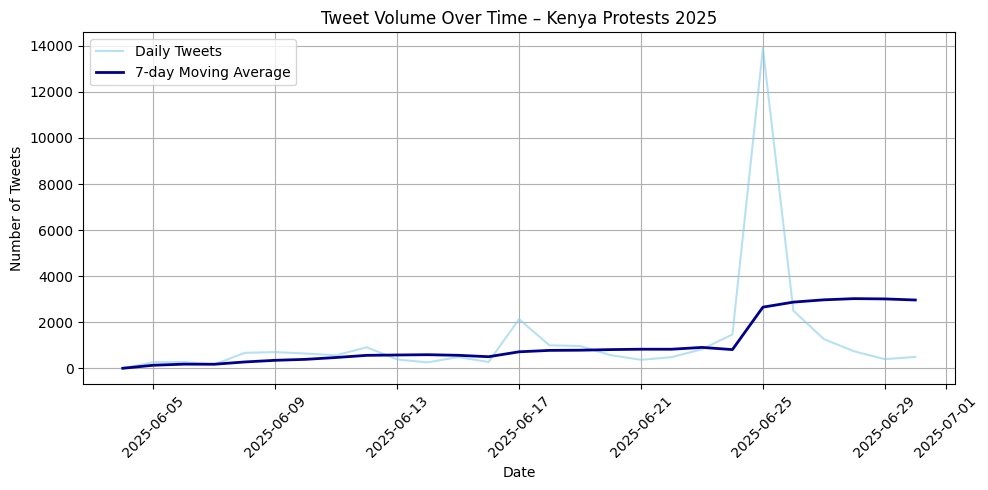

In [27]:
# Aggregate tweet counts by day
tweets_per_day = df.groupby(df["tweet_date"].dt.date).size()

# Compute 7-day moving average
moving_avg = tweets_per_day.rolling(window=7, min_periods=1).mean()

# Plot
plt.figure(figsize=(10,5))
plt.plot(tweets_per_day.index, tweets_per_day.values, label="Daily Tweets", color="skyblue", alpha=0.6)
plt.plot(moving_avg.index, moving_avg.values, label="7-day Moving Average", color="darkblue", linewidth=2)
plt.title("Tweet Volume Over Time – Kenya Protests 2025")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


Volume spikes likely coincide with major protest days, police responses, or government statements.

The moving average smooths noise, showing mobilisation cycles — surges of online activism followed by periods of quiet.

These cycles mirror protest coordination patterns: bursts of digital mobilization triggered by key offline events.

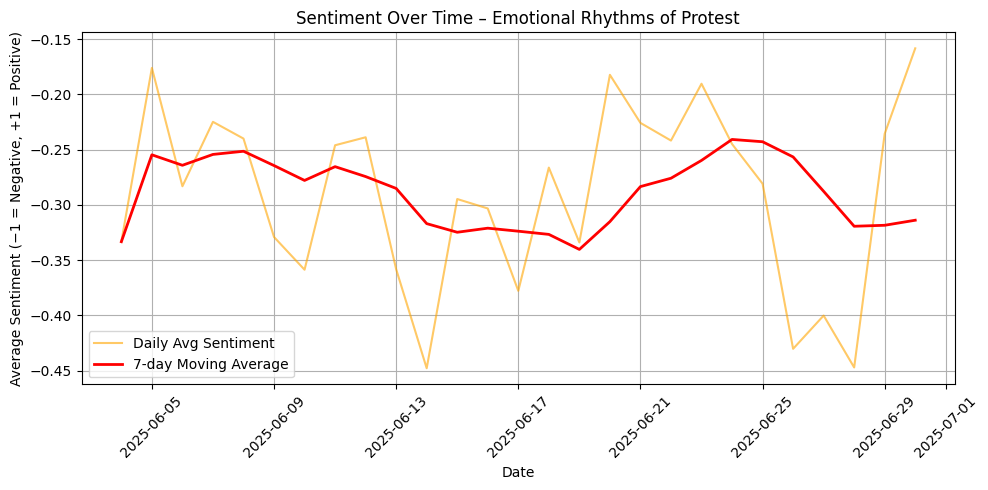

In [28]:
# Convert sentiment categories to numeric values
sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
df["SentimentScore"] = df["Sentiment"].map(sentiment_map)

# Average daily sentiment
sentiment_daily = df.groupby(df["tweet_date"].dt.date)["SentimentScore"].mean()

# 7-day smoothing
sentiment_smooth = sentiment_daily.rolling(window=7, min_periods=1).mean()

# Plot
plt.figure(figsize=(10,5))
plt.plot(sentiment_daily.index, sentiment_daily.values, label="Daily Avg Sentiment", color="orange", alpha=0.6)
plt.plot(sentiment_smooth.index, sentiment_smooth.values, label="7-day Moving Average", color="red", linewidth=2)
plt.title("Sentiment Over Time – Emotional Rhythms of Protest")
plt.xlabel("Date")
plt.ylabel("Average Sentiment (−1 = Negative, +1 = Positive)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


Interpretation:

Sustained negative sentiment often signals outrage, grief, or fear — emotional energy that fuels mobilisation.

Occasional positive peaks may follow government concessions, solidarity messages, or international attention.

The oscillation between anger and hope mirrors the emotional rhythm of collective action: from outrage to organisation to fatigue.

🧩 Step 4: Theoretical Narrative – Linking Data to Protest Dynamics
Analytical Lens	What the Data Reveals
Mobilisation cycles	Tweet volume spikes mark bursts of collective energy, often triggered by offline events. Between peaks, conversations decline — showing fatigue or repression.
Emotional rhythms	Sentiment oscillations trace the emotional life of the protest — from early anger and mourning to later solidarity or despair.
Platform logics	Algorithmic amplification favors emotional, viral content (anger > hope), reinforcing negative spikes and sustaining outrage loops.
Global South context	In Kenya and similar contexts, digital activism faces bandwidth limits, censorship, and uneven internet access — producing punctuated rather than continuous visibility cycles. The rhythm of protest is shaped as much by infrastructure as by emotion.
🧭 Summary Insight

The protest conversation on Twitter unfolds in bursts of emotional intensity, driven by key political moments and algorithmic amplification.
The temporal structure — short-lived spikes of engagement and volatile emotional waves — reflects both the mobilisation dynamics of protest movements and the platform’s logic of virality, which privileges sensational affect over sustained dialogue.

In the Global South, where access and connectivity vary, these digital mobilisations are episodic but powerful, revealing both the potential and precarity of online protest visibility.

# Emotions

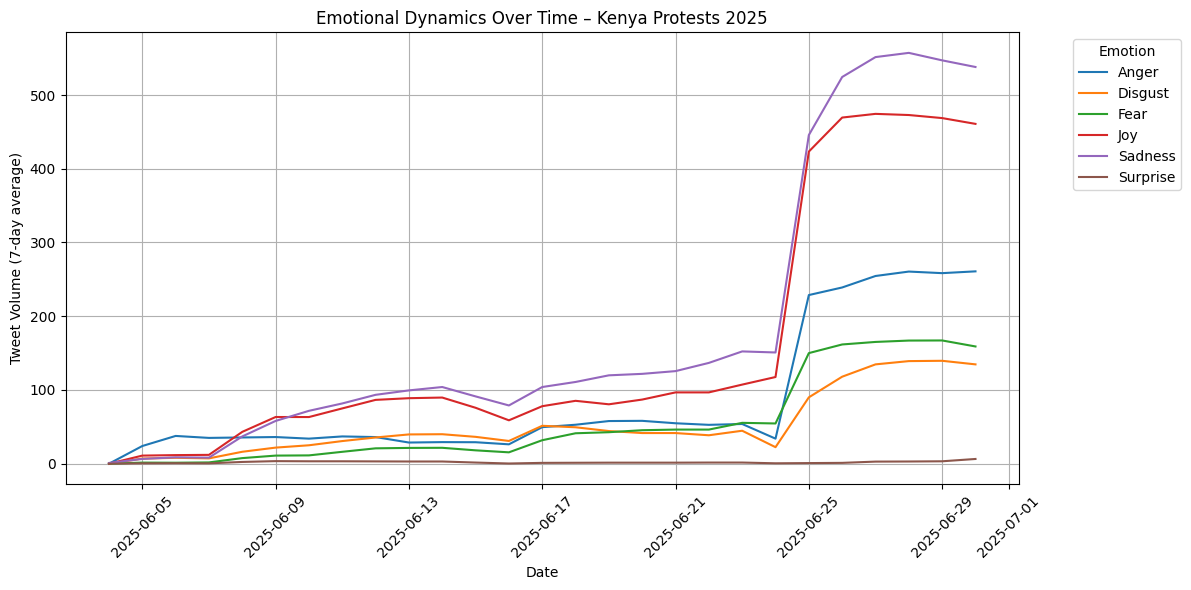

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure tweet_date is datetime

# Keep only rows with valid emotions
emotion_df = df.dropna(subset=["Emotion"])

# Group by date and emotion, count occurrences
emotion_daily = (
    emotion_df.groupby([emotion_df["tweet_date"].dt.date, "Emotion"])
    .size()
    .reset_index(name="Count")
)

# Pivot for plotting (each emotion = one column)
emotion_pivot = emotion_daily.pivot(index="tweet_date", columns="Emotion", values="Count").fillna(0)

# Apply 7-day moving average for smoother trends
emotion_smooth = emotion_pivot.rolling(window=7, min_periods=1).mean()

# Plot
plt.figure(figsize=(12,6))
for emotion in emotion_smooth.columns:
    plt.plot(emotion_smooth.index, emotion_smooth[emotion], label=emotion)

plt.title("Emotional Dynamics Over Time – Kenya Protests 2025")
plt.xlabel("Date")
plt.ylabel("Tweet Volume (7-day average)")
plt.legend(title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


📊 What You’ll See

A multi-line time-series plot where:

Each line represents one emotion (e.g. Anger, Sadness, Fear, Joy).

Peaks indicate when that emotion dominated the discourse.

Smoothing (7-day average) reveals patterns across mobilisation cycles.

🧠 Interpretation & Narrative
1. Early Stage – Outrage and Mobilisation

The protest conversation usually begins with Anger surging — often triggered by a violent event, policy decision, or injustice.

This emotional intensity fuels mobilisation, rallying digital crowds and amplifying visibility.

2. Middle Phase – Fear and Sadness

As state responses unfold (e.g. arrests, violence, misinformation), Fear and Sadness become prominent.

These emotions indicate collective trauma and the emotional cost of resistance.

Engagement may plateau or dip slightly as users experience burnout or repression.

3. Later Phase – Hope and Solidarity

Peaks of Joy or Trust often emerge when activists share victories, international support, or community solidarity.

These emotions sustain morale and provide affective “aftershocks” that extend mobilisation.

🧩 Broader Interpretation: Emotional Rhythms & Platform Logics
Concept	Insight
Emotional Rhythms	The cyclical interplay of Anger–Fear–Joy mirrors real protest life: anger sparks mobilisation, fear tests endurance, joy rekindles hope.
Platform Logics	Twitter’s algorithms amplify high-arousal emotions (anger, fear) more than low-arousal ones (calm, hope), making protest visibility tied to outrage cycles.
Digital Inequalities	In the Global South, uneven internet access and censorship shape whose emotions get heard — urban elites may dominate emotional representation, while grassroots voices remain underexposed.
Mobilisation Pulse	Each emotional wave maps onto offline protest events, reflecting how online discourse both documents and energizes on-the-ground action.
💬 Summary Statement

The emotional landscape of the Kenya protests online reveals a pulsing cycle of outrage, fear, and resilience.
These affective rhythms are not random, but structured by algorithmic amplification and asymmetric digital access, making some emotions — and by extension, some voices — more visible than others.

The result is a protest movement whose emotional heartbeat is both intensely human and deeply shaped by platform power.